# Anomalous diffusion and coarse-graining
These notebooks accompany the first part of the course.

Main topics:
1. 1D continuous-time random walks (CTRWs).
2. Markovian benchmark dynamics.
3. Power-law waiting times and anomalous diffusion.
4. Ensemble-averaged and time-averaged MSD.
5. Weak ergodicity breaking.
6. Decimation and lumping as coarse-graining procedures.
7. Homework: iterative RG for decimation.

Throughout, we use simple NumPy/Matplotlib code so that the core ideas remain visible.


In this notebook, some sections are already completed, while others contain prompts and `TODO` blocks for you to fill in.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

rng = np.random.default_rng(12345)

### Functions checkpoint
Here are stored the functions used throughout the notebook. Executing this cell grants that every other following cell can be autonomously executed. Some comments might be omitted for brevity.

In [ ]:
def simulate_markov_dt(T=100.0, dt=0.01, r=1.2, l=0.8, x0=0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    n_steps = int(T / dt)
    times = np.linspace(0.0, T, n_steps + 1)
    x = np.empty(n_steps + 1, dtype=float)
    x[0] = x0
    p_r = r * dt
    p_l = l * dt
    if p_r + p_l > 1:
        raise ValueError("Choose a smaller dt so that (r+l)dt <= 1.")
    u = rng.random(n_steps)
    step = np.zeros(n_steps, dtype=int)
    step[u < p_r] = 1
    step[(u >= p_r) & (u < p_r + p_l)] = -1
    x[1:] = x0 + np.cumsum(step)
    return times, x

def simulate_markov_gillespie(T=100.0, r=1.2, l=0.8, x0=0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    # Initialize
    lam = r+l
    pi_r = r/lam
    pi_l = l/lam
    times = []
    # Extract waiting times
    t = 0
    while t < T:
        tau = rng.exponential(scale=1/lam)
        t = t+tau
        if t > T:
            times.append(T)
            break
        times.append(t)
    times = np.asarray(times)
    # Extract jumps
    njumps = len(times)
    rands = rng.random(size=njumps)
    mask = np.ones(njumps)
    mask[rands < pi_l] = -1
    trajectory = np.cumsum(mask) + x0
    return times, trajectory

def make_plot_friendly(t, x, T, x0):
    # Add "dummy" final point
    t = np.append(t, T)
    x = np.append(x, x[-1])
    # Add initial point
    t = np.flip(np.append(np.flip(t),0))
    x = np.flip(np.append(np.flip(x),x0))
    return t, x

def simulate_markov_gillespie_asplot(T=100.0, r=1.2, l=0.8, x0=0, rng=None):
    # Compute trajectory
    t, x = simulate_markov_gillespie(T=T, r=r, l=l, x0=x0, rng=rng)
    # Add initial and final points
    t, x = make_plot_friendly(t, x, T, x0)
    return t, x

def sample_piecewise_on_grid(event_times, event_pos, t_grid):
    idx = np.searchsorted(event_times, t_grid, side="right") - 1
    idx = np.clip(idx, 0, len(event_pos) - 1)
    return event_pos[idx]

def generate_markov_ensemble(n_traj=500, T=100.0, n_grid=400, r=1.2, l=0.8, x0=0, rng=None):
    # Note that the initial point (0,x0) is NOT appended at the beginning, nor is the "final" point (x[-1] at time T)
    if rng is None:
        rng = np.random.default_rng()
    t_grid = np.linspace(0, T, n_grid)
    X = np.empty((n_grid, n_traj))
    for k in range(n_traj):
        t, x = simulate_markov_gillespie(T=T, r=r, l=l, x0=x0, rng=rng)
        event_pos = np.arange(len(x))
        mask = sample_piecewise_on_grid(t, event_pos, t_grid)
        X[:,k] = x[mask]
    return t_grid, X

def analyze_ensemble(times, X, x0, T):
    nsteps, ntraj = np.shape(X)
    # scaled cumulants (initial NaN values are forced to zero)
    scaled_mean = np.mean(X[1:,:], axis=1) / times[1:]
    scaled_mean = np.flip(np.append(np.flip(scaled_mean), 0))
    scaled_var  = np.var(X[1:,:], axis=1) / times[1:]
    scaled_var  = np.flip(np.append(np.flip(scaled_var), 0))
    # ensemble-averaged MSD
    displacement = (X - x0)**2
    eamsd = np.mean(displacement, axis=1)
    # time-averaged MSD
    tamsd_cols = []
    for k in range(ntraj):
        lags, tamsd_k = compute_tamsd(X[:, k])
        tamsd_cols.append(tamsd_k)
    tamsd = np.column_stack(tamsd_cols)
    mean_tamsd = np.mean(tamsd, axis=1)
    return scaled_mean, scaled_var, eamsd, mean_tamsd, lags

def sample_power_law_waiting(alpha, tau0=1., size=None, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    if size is None:
        rand = rng.uniform()
        y = tau0*((1-rand)**(-1/alpha) - 1)
    else:
        rand = rng.uniform(size=size)
        y = tau0*((1-rand)**(-1/alpha) - 1)
    return y

def simulate_powerlaw_ctrw(T=1000.0, alpha=0.7, tau0=1.0, p_right=0.5, x0=0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    # Extract waiting times
    times = []
    t = 0
    while t < T:
        tau = sample_power_law_waiting(alpha, tau0)
        t = t+tau
        if t > T:
            times.append(T)
            break
        times.append(t)
    times = np.asarray(times)
    # Extract jumps
    njumps = len(times)-1
    rands = rng.random(size=njumps)
    mask = np.ones(njumps)
    mask[rands > p_right] = -1
    trajectory = np.cumsum(mask) + x0
    trajectory = np.flip(np.append(np.flip(trajectory), x0))
    return times, trajectory

def generate_powerlaw_ensemble(n_traj=300, T=5000.0, n_grid=500, alpha=0.7, tau0=1.0, p_right=0.5, x0=0, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    t_grid = np.linspace(0, T, n_grid)
    X = np.empty((n_grid, n_traj))

    for k in range(n_traj):
        times, x = simulate_powerlaw_ctrw(T=T, alpha=alpha, tau0=tau0, p_right=p_right, x0=x0, rng=rng)
        event_pos = np.arange(len(x))
        mask = sample_piecewise_on_grid(times, event_pos, t_grid)
        X[:,k] = x[mask]
    return t_grid, X

def compute_tamsd(x):
    nsteps = len(x)
    lags = np.asarray(range(1, int(nsteps/5)))
    tamsd = np.zeros(len(lags))
    for lag in lags:
        diff = x[lag:] - x[:-lag]
        tamsd[lag-1] = np.sum(diff**2) / (nsteps-lag)
    return lags, tamsd

def decimate(times, trajectory, mask_function):
    # create decimation mask and decimated vectors
    mask = np.array([mask_function(val) for val in trajectory], dtype=bool)
    dec_trajectory = trajectory[mask]
    dec_times = times[mask]
    # build coarse-indexed trajectory (~rescaling)
    unique_values, coarse_trajectory_pos = np.unique(dec_trajectory, return_index=True)
    neg_count = np.sum((unique_values < 0).astype(int))
    coarse_trajectory = np.asarray([k - neg_count for k in coarse_trajectory_pos])
    coarse_times = dec_times[coarse_trajectory_pos]
    return dec_times, dec_trajectory, coarse_times, coarse_trajectory

def collect_decimated_waiting_times(mask_function, n_traj=1000, T=1000.0, alpha=1., tau0=1., p_right=0.5, x0=0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    all_cumulative_waiting_times = []
    k = 0
    while k<n_traj:
        times, trajectory = simulate_powerlaw_ctrw(T=T, alpha=alpha, tau0=tau0, p_right=p_right, x0=x0, rng=rng)
        _, _, dec_times, _ = decimate(times, trajectory, mask_function)
        all_cumulative_waiting_times.append(np.diff(dec_times))
        k += 1
    cumulative_waiting_times = np.concatenate(all_cumulative_waiting_times)
    lower = cumulative_waiting_times.min()
    if lower <= 0:
        lower = 1e-8
    higher = cumulative_waiting_times.max()
    n_bins = 50
    bin_edges = np.logspace(np.log10(lower), np.log10(higher), n_bins)
    values, bin_edges = np.histogram(cumulative_waiting_times, bins=bin_edges)
    bins = np.sqrt(bin_edges[:-1] * bin_edges[1:])
    return bins, values

def lump(times, trajectory, block_length):
    lump_trajectory = trajectory // block_length
    mask = np.concatenate(([True], lump_trajectory[1:] != lump_trajectory[:-1]))
    lump_ind = np.where(mask)[0]
    lump_times = times[lump_ind]
    lump_trajectory = lump_trajectory[lump_ind]
    return np.array(lump_times), np.array(lump_trajectory)

def collect_lumped_waiting_times(block_length, n_traj=1000, T=1000.0, alpha=1., tau0=1., p_right=0.5, x0=0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    all_cumulative_waiting_times = []
    k = 0
    while k<n_traj:
        times, trajectory = simulate_powerlaw_ctrw(T=T, alpha=alpha, tau0=tau0, p_right=p_right, x0=x0, rng=rng)
        lump_times, _ = lump(times, trajectory, block_length)
        all_cumulative_waiting_times.append(np.diff(lump_times))
        k += 1
    cumulative_waiting_times = np.concatenate(all_cumulative_waiting_times)
    lower = cumulative_waiting_times.min()
    if lower <= 0:
        lower = 1e-8
    higher = cumulative_waiting_times.max()
    n_bins = 50
    bin_edges = np.logspace(np.log10(lower), np.log10(higher), n_bins)
    values, bin_edges = np.histogram(cumulative_waiting_times, bins=bin_edges)
    bins = np.sqrt(bin_edges[:-1] * bin_edges[1:])
    return bins, values

## 1. Markov jump process in 1D with finite time step

At each time step $\Delta t$:
- jump right with probability $r\Delta t$,
- jump left with probability $\ell\Delta t$,
- otherwise remain on the same site.

Below there is a complete worked example.
Read it and run it before moving on.

In [2]:
def simulate_markov_dt(T=100.0, dt=0.01, r=1.2, l=0.8, x0=0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    
    n_steps = int(T/dt)
    times = np.linspace(0.0, T, n_steps + 1)
    x = np.empty(n_steps + 1, dtype=float)
    x[0] = x0

    p_r = r * dt
    p_l = l * dt
    if p_r + p_l > 1:
        raise ValueError("Choose a smaller dt so that (r+l)dt <= 1.")

    u = rng.random(n_steps)
    step = np.zeros(n_steps, dtype=int)
    step[u < p_r] = 1
    step[(u >= p_r) & (u < p_r + p_l)] = -1
    x[1:] = x0 + np.cumsum(step)

    return times, x

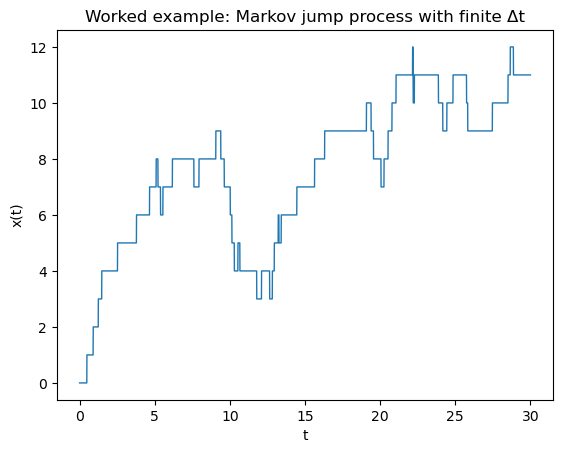

In [3]:
times, x = simulate_markov_dt(T=30, dt=0.01, r=1.2, l=0.8, rng=rng)
plt.plot(times, x, lw=1)
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Worked example: Markov jump process with finite Δt")
plt.show()

### Exercise 1.1
Modify the parameters:
- unbiased case: `r = l`,
- biased case: `r \neq l`,
- different values of `dt`.

What changes in the trajectory?
What happens if `dt` is chosen too large?

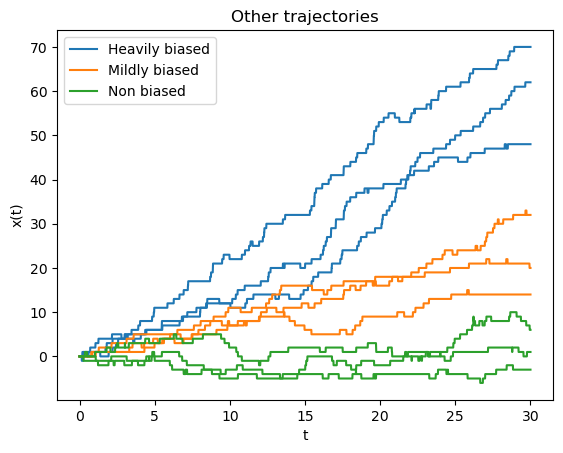

In [4]:
t_hb1, x_hb1 = simulate_markov_dt(T=30, dt=0.01, r=2., l=0.2, rng=rng)
t_hb2, x_hb2 = simulate_markov_dt(T=30, dt=0.01, r=2., l=0.2, rng=rng)
t_hb3, x_hb3 = simulate_markov_dt(T=30, dt=0.01, r=2., l=0.2, rng=rng)

t_b1, x_b1 = simulate_markov_dt(T=30, dt=0.01, r=1., l=0.25, rng=rng)
t_b2, x_b2 = simulate_markov_dt(T=30, dt=0.01, r=1., l=0.25, rng=rng)
t_b3, x_b3 = simulate_markov_dt(T=30, dt=0.01, r=1., l=0.25, rng=rng)

t1, x1 = simulate_markov_dt(T=30, dt=0.01, r=1., l=1., rng=rng)
t2, x2 = simulate_markov_dt(T=30, dt=0.01, r=1., l=1., rng=rng)
t3, x3 = simulate_markov_dt(T=30, dt=0.01, r=1., l=1., rng=rng)

plt.plot(t_hb1, x_hb1, c='C0', label='Heavily biased')
plt.plot(t_hb2, x_hb2, c='C0')
plt.plot(t_hb3, x_hb3, c='C0')

plt.plot(t_b1, x_b1, c='C1', label='Mildly biased')
plt.plot(t_b2, x_b2, c='C1')
plt.plot(t_b3, x_b3, c='C1')

plt.plot(t1, x1, c='C2', label='Non biased')
plt.plot(t2, x2, c='C2')
plt.plot(t3, x3, c='C2')

plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Other trajectories")
plt.legend()
plt.show()

It's clear that the "slope" of the biased trajectories gets steeper as $r-l$ gets larger.

Now, to understand what happens to the same trajectory if `dt` is changed, we plot randomly generated trajectories with the same parameters but different values of `dt`, up to the threshold value beyond which $(r+l)\Delta t \leq 1$ isn't true anymore. 

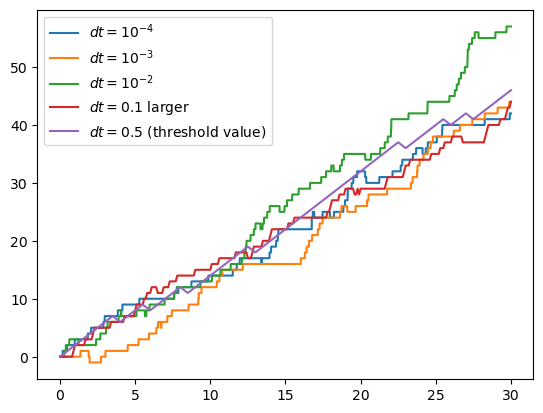

In [6]:
t_s, x_s = simulate_markov_dt(T=30, dt=0.0001, r=1.8, l=0.2, rng=rng)
t_m, x_m = simulate_markov_dt(T=30, dt=0.001, r=1.8, l=0.2, rng=rng)
t_l, x_l = simulate_markov_dt(T=30, dt=0.01, r=1.8, l=0.2, rng=rng)
t_xl, x_xl = simulate_markov_dt(T=30, dt=0.1, r=1.8, l=0.2, rng=rng)
t_th, x_th = simulate_markov_dt(T=30, dt=0.5, r=1.8, l=0.2, rng=rng)

plt.plot(t_s, x_s, label='$dt=10^{-4}$')
plt.plot(t_m, x_m, label='$dt=10^{-3}$')
plt.plot(t_l, x_l, label='$dt=10^{-2}$')
plt.plot(t_xl, x_xl, label='$dt=0.1$ larger')
plt.plot(t_th, x_th, label='$dt=0.5$ (threshold value)')

plt.legend()
plt.show()

The threshold trajectory exhibits no plateaus, since for each step the system can only jump left or right and isn't able to stay in place anymore. For trajectories in which `dt` is smaller, plateaus take place more and more frequently. In the following, the same procedure is followed for values of $dt$ close to the threshold.

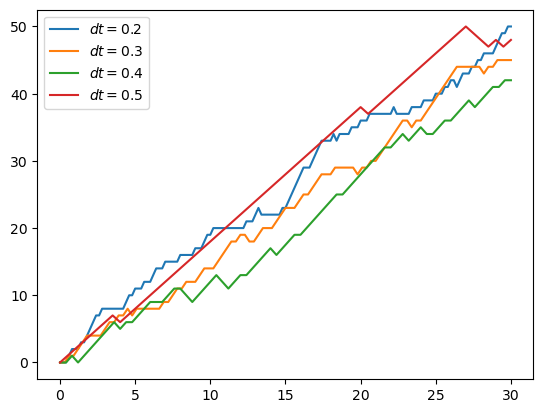

In [7]:
t_m, x_m = simulate_markov_dt(T=30, dt=0.2, r=1.8, l=0.2, rng=rng)
t_l, x_l = simulate_markov_dt(T=30, dt=0.3, r=1.8, l=0.2, rng=rng)
t_xl, x_xl = simulate_markov_dt(T=30, dt=0.4, r=1.8, l=0.2, rng=rng)
t_th, x_th = simulate_markov_dt(T=30, dt=0.5, r=1.8, l=0.2, rng=rng)

plt.plot(t_m, x_m, label='$dt = 0.2$')
plt.plot(t_l, x_l, label='$dt = 0.3$')
plt.plot(t_xl, x_xl, label='$dt = 0.4$')
plt.plot(t_th, x_th, label='$dt = 0.5$')

plt.legend()
plt.show()

As expected, the increase in the occurrence of plateaus becomes more evident for smaller values of `dt`, whereas the closer to the threshold the rarer they become. 

## 2. Gillespie simulation of the same process

For the exact continuous-time process:
- the total escape rate is $\lambda = r + \ell$,
- the residence time is exponentially distributed with density $\psi(\tau)=\lambda e^{-\lambda \tau}$,
- after a jump, the direction is chosen with probabilities
  $\pi_r = r/(r+\ell)$ and $\pi_\ell = \ell/(r+\ell)$.

This is the standard kinetic Monte Carlo / Gillespie construction.

### Exercise 2.1
Implement the Gillespie version.

Complete the function below:
1. draw a residence time from an exponential law with mean $1/(r+\ell)$,
2. choose the jump direction using $\pi_r$ and $\pi_\ell$,
3. build the piecewise-constant trajectory.

In [8]:
def simulate_markov_gillespie(T=100.0, r=1.2, l=0.8, x0=0, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    # initialize
    lam = r+l
    pi_r = r/lam
    pi_l = l/lam
    times = []

    # extract waiting times
    t = 0
    while t < T:
        tau = rng.exponential(scale=1/lam)
        t = t+tau
        if t > T:
            times.append(T)
            break
        times.append(t)
    times = np.asarray(times)

    # extract jumps
    njumps = len(times)
    rands = rng.random(size=njumps)
    mask = np.ones(njumps)
    mask[rands < pi_l] = -1
    trajectory = np.cumsum(mask) + x0

    return times, trajectory


def make_plot_friendly(t, x, T, x0):
    # Adds initial and final point. `t` and `x` should be numpy arrays.

    # add "dummy" final point
    t = np.append(t, T)
    x = np.append(x, x[-1])

    # add initial point
    t = np.flip(np.append(np.flip(t),0))
    x = np.flip(np.append(np.flip(x),x0))

    return t, x


def simulate_markov_gillespie_asplot(T=100.0, r=1.2, l=0.8, x0=0, rng=None):
    # Plot-friendly wrapper for `simulate_markov_gillespie`

    # Compute trajectory
    t, x = simulate_markov_gillespie(T=T, r=r, l=l, x0=x0, rng=rng)
    
    # Add initial and final points
    t, x = make_plot_friendly(t, x, T, x0)

    return t, x

### Test plot
Note that `matplotlib.pyplot.step()` is used with the argument `where='mid'` for visualization purposes, but *it may not reflect* the microscopically-accurate distribution of residence times as the step is plotted halfway between the jumps.

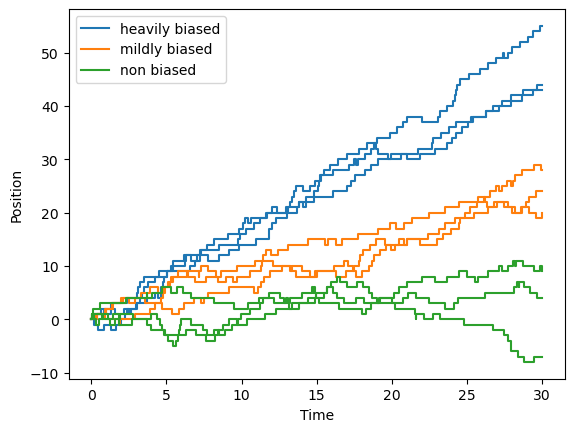

In [12]:
T = 30.
x0 = 0

# Generate

t_hb1, x_hb1 = simulate_markov_gillespie_asplot(T=T, r=1.8, l=0.2, x0=x0, rng=None)
t_hb2, x_hb2 = simulate_markov_gillespie_asplot(T=T, r=1.8, l=0.2, x0=x0, rng=None)
t_hb3, x_hb3 = simulate_markov_gillespie_asplot(T=T, r=1.8, l=0.2, x0=x0, rng=None)

t_b1, x_b1 = simulate_markov_gillespie_asplot(T=T, r=1.5, l=0.5, x0=x0, rng=None)
t_b2, x_b2 = simulate_markov_gillespie_asplot(T=T, r=1.5, l=0.5, x0=x0, rng=None)
t_b3, x_b3 = simulate_markov_gillespie_asplot(T=T, r=1.5, l=0.5, x0=x0, rng=None)

t1, x1 = simulate_markov_gillespie_asplot(T=T, r=1., l=1., x0=x0, rng=None)
t2, x2 = simulate_markov_gillespie_asplot(T=T, r=1., l=1., x0=x0, rng=None)
t3, x3 = simulate_markov_gillespie_asplot(T=T, r=1., l=1., x0=x0, rng=None)

# Plot

plt.step(t_hb1, x_hb1, c='C0', where='mid', label='heavily biased')
plt.step(t_hb2, x_hb2, c='C0', where='mid')
plt.step(t_hb3, x_hb3, c='C0', where='mid')

plt.step(t_b1, x_b1, c='C1', where='mid', label='mildly biased')
plt.step(t_b2, x_b2, c='C1', where='mid')
plt.step(t_b3, x_b3, c='C1', where='mid')

plt.step(t1, x1, c='C2', where='mid', label='non biased')
plt.step(t2, x2, c='C2', where='mid')
plt.step(t3, x3, c='C2', where='mid')

plt.xlabel('Time')
plt.ylabel('Position')
plt.legend()
plt.show()

## 3. Extracting scaled cumulants and checking diffusive growth

For many trajectories, estimate:
- the average current $\langle x(t)\rangle/t$,
- the scaled variance $\mathrm{Var}[x(t)]/t$,
- the ensemble MSD.

The goal is to verify that the Markov case is normally diffusive.

In [ ]:
def sample_piecewise_on_grid(event_times, event_pos, t_grid):
    idx = np.searchsorted(event_times, t_grid, side="right") - 1
    idx = np.clip(idx, 0, len(event_pos) - 1)
    return event_pos[idx]

def generate_markov_ensemble(n_traj=500, T=100.0, n_grid=400, r=1.2, l=0.8, x0=0, rng=None):
    # Note that the initial point (0,x0) is NOT appended at the beginning, nor is the "final" point (x[-1] at time T)
    if rng is None:
        rng = np.random.default_rng()

    t_grid = np.linspace(0, T, n_grid)
    X = np.empty((n_grid, n_traj))

    for k in range(n_traj):
        t, x = simulate_markov_gillespie(T=T, r=r, l=l, x0=x0, rng=rng)
        event_pos = np.arange(len(x))
        mask = sample_piecewise_on_grid(t, event_pos, t_grid)
        X[:,k] = x[mask]

    return t_grid, X

def analyze_ensemble(times, X, x0, T):
    # Note: the function computes the time-averaged MSD as well as the other cumulants in accordance with requests made later in the notebook.
    nsteps, ntraj = np.shape(X)

    # scaled cumulants (initial NaN values are forced to zero)
    scaled_mean = np.mean(X[1:,:], axis=1) / times[1:]
    scaled_mean = np.flip(np.append(np.flip(scaled_mean), 0))
    scaled_var  = np.var(X[1:,:], axis=1) / times[1:]
    scaled_var  = np.flip(np.append(np.flip(scaled_var), 0))

    # ensemble-averaged MSD
    displacement = (X - x0)**2
    eamsd = np.mean(displacement, axis=1)

    # time-averaged MSD
    tamsd_cols = []
    for k in range(ntraj):
        lags, tamsd_k = compute_tamsd(X[:, k])
        tamsd_cols.append(tamsd_k)

    tamsd = np.column_stack(tamsd_cols)
    mean_tamsd = np.mean(tamsd, axis=1)

    return scaled_mean, scaled_var, eamsd, mean_tamsd, lags

### Scaled cumulants

In [ ]:
x0 = 0.
T = 1000.

t_grid, X_hb = generate_markov_ensemble(n_traj = 500, T=T, n_grid=400, r=2., l=0.2, x0=x0, rng=None)
_, X_b = generate_markov_ensemble(n_traj=500, T=T, n_grid=400, r=1.5, l=0.5, x0=x0, rng=None)
_, X_0 = generate_markov_ensemble(n_traj=500, T=T, n_grid=400, r=1., l=1., x0=x0, rng=None)

scaled_mean_hb, scaled_var_hb, eamsd_hb, _, _ = analyze_ensemble(t_grid, X_hb, x0, T)
scaled_mean_b, scaled_var_b, eamsd_b, _, _ = analyze_ensemble(t_grid, X_b, x0, T)
scaled_mean_0, scaled_var_0, eamsd_0, _, _ = analyze_ensemble(t_grid, X_0, x0, T)

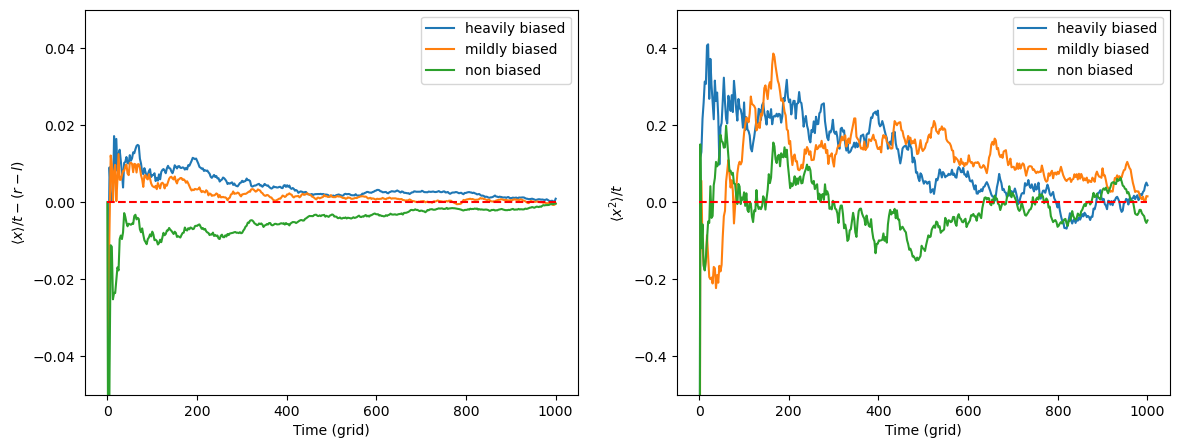

In [18]:
fig, ax = plt.subplots(1,2, figsize=(14,5))
ax = ax.flatten()

# mean
ax[0].plot(t_grid, scaled_mean_hb-1.8, label='heavily biased')
ax[0].plot(t_grid, scaled_mean_b-1., label='mildly biased')
ax[0].plot(t_grid, scaled_mean_0, label='non biased')
ax[0].set_xlabel('Time (grid)')
ax[0].set_ylabel(r'$\langle x \rangle / t - (r-l)$')
ax[0].set_ylim([-0.05,0.05])
ax[0].plot([0,1000], [0., 0.], 'r--')
ax[0].legend()

# variance
ax[1].plot(t_grid, scaled_var_hb-2., label='heavily biased')
ax[1].plot(t_grid, scaled_var_b-2., label='mildly biased')
ax[1].plot(t_grid, scaled_var_0-2., label='non biased')
ax[1].set_xlabel('Time (grid)')
ax[1].set_ylabel(r'$\langle x^2 \rangle /t$')
ax[1].set_ylim([-0.5, 0.5])
ax[1].plot([0,1000], [0., 0.], 'r--')
ax[1].legend()

plt.show()

The scaled means quickly converge to the $r-l$ limit. The scaled variance should converge to:
$$
S^* = \lambda - \frac{(r-l)^2}{\lambda}
$$

but the resolution doesn't allow for a visual appreciation of the limit. The reason becomes clear considering that knowing every scaled cumulant is equivalent to knowing the exact probability distribution, which of course can only be determined by knowing an infinite number of trajectories. The point is that higher-order scaled cumulants require more and more trajectories to work with: the statistic of the problem must increase according to the precision required a priori.

The following is a graph showing quicker and quicker convegence to the scaled variance limit $S^*$, for ensembles with an increasing number of trajectories.

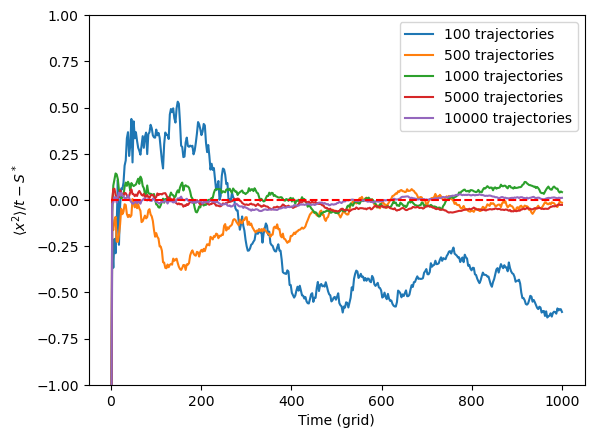

In [22]:
x0 = 0.
N = [100, 500, 1000, 5000, 10000]


for k in range(len(N)):
    t, x = generate_markov_ensemble(n_traj=N[k], T=1000.0, n_grid=400, r=1., l=1., x0=x0, rng=None)
    _, scaled_var, _, _, _ = analyze_ensemble(t, x, x0, T)
    plt.plot(t, scaled_var-2., label=f'{N[k]} trajectories')

plt.plot([0,1000], [0., 0.], 'r--')
plt.ylim([-1, 1])
plt.xlabel('Time (grid)')
plt.ylabel(r'$\langle x^2 \rangle / t - S^*$')
plt.legend()
plt.show()

### Ensemble-Averaged MSD
As expected, the MSD increases linearly for the non-biased trajectory, while it undergoes an initial "ballistic" phase for the biased trajectories. In the latter cases, the ballistic portion becomes more pronounced with the bias. The curves still converge to a linear asymptote.

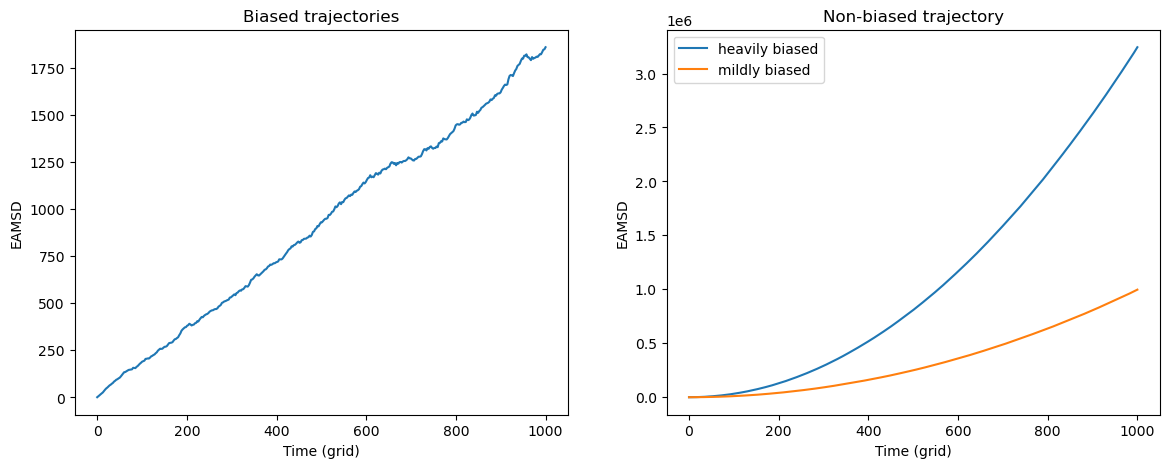

In [ ]:
fig,ax = plt.subplots(1,2, figsize=(14,5))
ax = ax.flatten()

ax[0].plot(t_grid, eamsd_0)
ax[0].set_title('Biased trajectories')
ax[0].set_ylabel('EAMSD')
ax[0].set_xlabel('Time (grid)')

ax[1].plot(t_grid, eamsd_hb, label='heavily biased')
ax[1].plot(t_grid, eamsd_b, label='mildly biased')
ax[1].set_title('Non-biased trajectory')
ax[1].set_xlabel('Time (grid)')
ax[1].set_ylabel('EAMSD')
ax[1].legend()

plt.show()

### Time-averaged MSD
As an example of weak ergodicity breaking, we plot the TAMSD of the first 10 unbiased trajectories. The MSD is linearly dependent on the lag time.

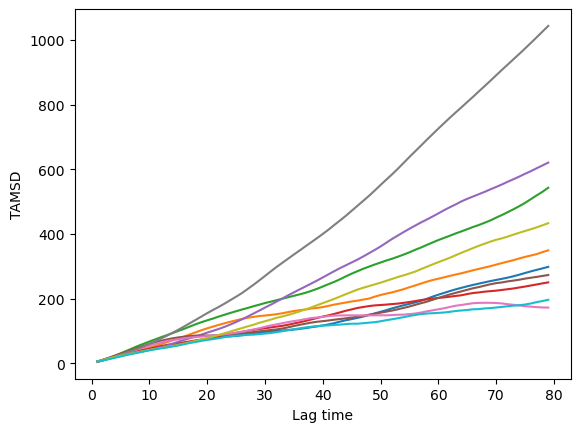

In [23]:
for k in range(10):
    traj = X_0[:,k]
    lags, tamsd_0 = compute_tamsd(traj)
    plt.plot(lags, tamsd_0)

plt.xlabel('Lag time')
plt.ylabel('TAMSD')
plt.show()

The following graph shows the dependance of the TAMSD on the total time span $T$ of the trajectory upon which we are averaging. Linearity is evident.

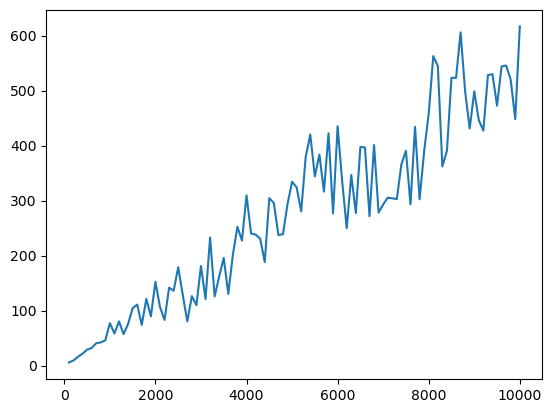

In [24]:
T = np.arange(100, 10001, 100)
x0 = 0.
tamsd_t = np.empty(len(T))

for k in range(len(T)):
    t, x = generate_markov_ensemble(n_traj=1, T=T[k], n_grid=400, r=1., l=1., x0=x0, rng=None)
    _, temp = compute_tamsd(x[:,0])
    tamsd_t[k] = temp[10]

plt.plot(T, tamsd_t)
plt.show()

## 4. CTRW with a power-law waiting time distribution

We now replace the exponential waiting time by a heavy-tailed law
$$
\psi(\tau) \sim \tau^{-1-\alpha}, \qquad 0<\alpha<1.
$$

A convenient exact sampler is obtained from a Pareto-type density
$$
\psi(\tau)=\frac{\alpha\tau_0^\alpha}{(\tau+\tau_0)^{1+\alpha}},
$$
which can be sampled through inverse transform.

This distribution has infinite mean waiting time for $0<\alpha<1$.
That is the source of subdiffusion and weak ergodicity breaking.

### Exercise 4.1
Implement a CTRW with a power-law waiting time distribution.

Use the inverse-transform formula for the waiting times.
Then simulate:
- free diffusion: `p_right = 0.5`,
- biased diffusion: `p_right > 0.5`.

In [ ]:
def sample_power_law_waiting(alpha, tau0=1., size=None, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    if size is None:
        rand = rng.uniform()
        y = tau0*((1-rand)**(-1/alpha) - 1)
    else:
        rand = rng.uniform(size=size)
        y = tau0*((1-rand)**(-1/alpha) - 1)

    return y


def simulate_powerlaw_ctrw(T=1000.0, alpha=0.7, tau0=1.0, p_right=0.5, x0=0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    
    # Extract waiting times
    times = []
    t = 0
    while t < T:
        tau = sample_power_law_waiting(alpha, tau0)
        t = t+tau
        if t > T:
            times.append(T)
            break
        times.append(t)
    times = np.asarray(times)

    # Extract jumps
    njumps = len(times)-1
    rands = rng.random(size=njumps)
    mask = np.ones(njumps)
    mask[rands > p_right] = -1
    trajectory = np.cumsum(mask) + x0
    trajectory = np.flip(np.append(np.flip(trajectory), x0))

    return times, trajectory

As shown below, lower values for the Pareto distribution exponent $\alpha$ generate longer plateaus more frequently in the trajectory. For easier visualization, only unbiased trajectories are considered.

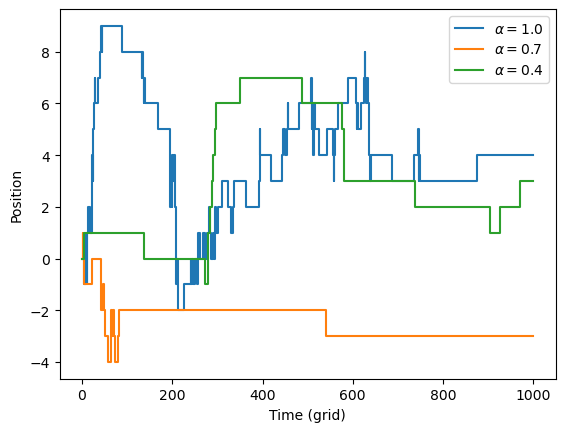

In [25]:
t_1, x_1 = simulate_powerlaw_ctrw(T=1000.0, alpha=1., tau0=1.0, p_right=0.5, x0=0, rng=None)
t_07, x_07 = simulate_powerlaw_ctrw(T=1000.0, alpha=0.7, tau0=1.0, p_right=0.5, x0=0, rng=None)
t_04, x_04 = simulate_powerlaw_ctrw(T=1000.0, alpha=0.4, tau0=1.0, p_right=0.5, x0=0, rng=None)

plt.step(t_1, x_1, where='mid', label=r'$\alpha=1.0$')
plt.step(t_07, x_07, where='mid', label=r'$\alpha=0.7$')
plt.step(t_04, x_04, where='mid', label=r'$\alpha=0.4$')

plt.xlabel('Time (grid)')
plt.ylabel('Position')
plt.legend()
plt.show()


## 5. EAMSD, TEAMSD, anomalous exponents, and weak ergodicity breaking

For each trajectory sampled on a common observation grid, we can compute:

- EAMSD:
$$
\langle [x(t)-x(0)]^2 \rangle
$$

- time-averaged MSD (for lag $\Delta$):
$$
\overline{\delta^2(\Delta)}
=
\frac{1}{T-\Delta}
\int_0^{T-\Delta}
[x(t+\Delta)-x(t)]^2\,dt \sim \Delta \cdot T^{\,\alpha-1}
$$

For subdiffusive CTRWs:
- unbiased case: EAMSD $\sim t^\alpha$,
- biased case: EAMSD of the displacement typically shows stronger growth, asymptotically $\sim t^{2\alpha}$ when the drift dominates, while fluctuations around the mean remain sublinear,
- TEAMSD behaves differently from EAMSD, revealing weak ergodicity breaking.

### Exercise 5.1
Generate enough trajectories and estimate:
- the EAMSD for the free case,
- the EAMSD for the biased case,
- a collection of TAMSD curves.

You should then discuss:
1. the qualitative appearance of the trajectories,
2. the relation between $\alpha$ and the MSD exponent,
3. the evidence of weak ergodicity breaking.

In [ ]:
def generate_powerlaw_ensemble(n_traj=300, T=5000.0, n_grid=500, alpha=0.7, tau0=1.0, p_right=0.5, x0=0, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    t_grid = np.linspace(0, T, n_grid)
    X = np.empty((n_grid, n_traj))

    for k in range(n_traj):
        times, x = simulate_powerlaw_ctrw(T=T, alpha=alpha, tau0=tau0, p_right=p_right, x0=x0, rng=rng)
        event_pos = np.arange(len(x))
        mask = sample_piecewise_on_grid(times, event_pos, t_grid)
        X[:,k] = x[mask]

    return t_grid, X

def compute_tamsd(x):
    nsteps = len(x)
    lags = np.asarray(range(1, int(nsteps/5)))
    tamsd = np.zeros(len(lags))
    for lag in lags:
        diff = x[lag:] - x[:-lag]
        tamsd[lag-1] = np.sum(diff**2) / (nsteps-lag)
    return lags, tamsd

We create a wide workspace to account for all possible perspectives. The graphs below check the EAMSD behaviour.

##### Simulating and saving data

In [ ]:
# Warning: this cell may take several minutes to run. It is advised to run the next cell, where data are loaded from previous simulations.

n_traj = 1000
T = 50000.
n_grid = 1000


###### UNBIASED ######
# alpha = 1. (markovian)
t_grid_1, X_1 = generate_powerlaw_ensemble(n_traj = n_traj, T=T, n_grid=n_grid, alpha=1., tau0=1.0, p_right=0.5, rng=None)
sc_mean_1, sc_var_1, eamsd_1, tamsd_1, lags_1 = analyze_ensemble(t_grid_1, X_1, 0,5000.)
# alpha = 0.7
t_grid_07, X_07 = generate_powerlaw_ensemble(n_traj = n_traj, T=T, n_grid=n_grid, alpha=0.7, tau0=1.0, p_right=0.5, rng=None)
sc_mean_07, sc_var_07, eamsd_07, tamsd_07, lags_07 = analyze_ensemble(t_grid_07, X_07, 0,5000.)
# alpha = 0.4
t_grid_04, X_04 = generate_powerlaw_ensemble(n_traj = n_traj, T=T, n_grid=n_grid, alpha=0.4, tau0=1.0, p_right=0.5, rng=None)
sc_mean_04, sc_var_04, eamsd_04, tamsd_04, lags_04 = analyze_ensemble(t_grid_04, X_04, 0,5000.)

######## BIASED ########
# alpha = 1. (markovian)
t_grid_b_1, X_b_1 = generate_powerlaw_ensemble(n_traj = n_traj, T=T, n_grid=n_grid, alpha=1., tau0=1.0, p_right=0.7, rng=None)
sc_mean_b_1, sc_var_b_1, eamsd_b_1, tamsd_b_1, lags_b_1 = analyze_ensemble(t_grid_b_1, X_b_1, 0,5000.)
# alpha = 0.7
t_grid_b_07, X_b_07 = generate_powerlaw_ensemble(n_traj = n_traj, T=T, n_grid=n_grid, alpha=0.7, tau0=1.0, p_right=0.7, rng=None)
sc_mean_b_07, sc_var_b_07, eamsd_b_07, tamsd_b_07, lags_b_07 = analyze_ensemble(t_grid_b_07, X_b_07, 0,5000.)
# alpha = 0.4
t_grid_b_04, X_b_04 = generate_powerlaw_ensemble(n_traj = n_traj, T=T, n_grid=n_grid, alpha=0.4, tau0=1.0, p_right=0.7, rng=None)
sc_mean_b_04, sc_var_b_04, eamsd_b_04, tamsd_b_04, lags_b_04 = analyze_ensemble(t_grid_b_04, X_b_04, 0,5000.)

#### HEAVILY BIASED ####
# alpha = 1. (markovian)
t_grid_hb_1, X_hb_1 = generate_powerlaw_ensemble(n_traj = n_traj, T=T, n_grid=n_grid, alpha=1., tau0=1.0, p_right=0.9, rng=None)
sc_mean_hb_1, sc_var_hb_1, eamsd_hb_1, tamsd_hb_1, lags_hb_1 = analyze_ensemble(t_grid_hb_1, X_hb_1, 0,5000.)
# alpha = 0.7
t_grid_hb_07, X_hb_07 = generate_powerlaw_ensemble(n_traj = n_traj, T=T, n_grid=n_grid, alpha=0.7, tau0=1.0, p_right=0.9, rng=None)
sc_mean_hb_07, sc_var_hb_07, eamsd_hb_07, tamsd_hb_07, lags_hb_07 = analyze_ensemble(t_grid_hb_07, X_hb_07, 0,5000.)
# alpha = 0.4
t_grid_hb_04, X_hb_04 = generate_powerlaw_ensemble(n_traj = n_traj, T=T, n_grid=n_grid, alpha=0.4, tau0=1.0, p_right=0.9, rng=None)
sc_mean_hb_04, sc_var_hb_04, eamsd_hb_04, tamsd_hb_04, lags_hb_04 = analyze_ensemble(t_grid_hb_04, X_hb_04, 0,5000.)

np.savez(
    'ex5_data.npz',
    # UNBIASED
    t_grid_1=t_grid_1, X_1=X_1,
    sc_mean_1=sc_mean_1, sc_var_1=sc_var_1, eamsd_1=eamsd_1, tamsd_1=tamsd_1, lags_1=lags_1,

    t_grid_07=t_grid_07, X_07=X_07,
    sc_mean_07=sc_mean_07, sc_var_07=sc_var_07, eamsd_07=eamsd_07, tamsd_07=tamsd_07, lags_07=lags_07,

    t_grid_04=t_grid_04, X_04=X_04,
    sc_mean_04=sc_mean_04, sc_var_04=sc_var_04, eamsd_04=eamsd_04, tamsd_04=tamsd_04, lags_04=lags_04,

    # BIASED
    t_grid_b_1=t_grid_b_1, X_b_1=X_b_1,
    sc_mean_b_1=sc_mean_b_1, sc_var_b_1=sc_var_b_1, eamsd_b_1=eamsd_b_1, tamsd_b_1=tamsd_b_1, lags_b_1=lags_b_1,

    t_grid_b_07=t_grid_b_07, X_b_07=X_b_07,
    sc_mean_b_07=sc_mean_b_07, sc_var_b_07=sc_var_b_07, eamsd_b_07=eamsd_b_07, tamsd_b_07=tamsd_b_07, lags_b_07=lags_b_07,

    t_grid_b_04=t_grid_b_04, X_b_04=X_b_04,
    sc_mean_b_04=sc_mean_b_04, sc_var_b_04=sc_var_b_04, eamsd_b_04=eamsd_b_04, tamsd_b_04=tamsd_b_04, lags_b_04=lags_b_04,

    # HEAVILY BIASED
    t_grid_hb_1=t_grid_hb_1, X_hb_1=X_hb_1,
    sc_mean_hb_1=sc_mean_hb_1, sc_var_hb_1=sc_var_hb_1, eamsd_hb_1=eamsd_hb_1, tamsd_hb_1=tamsd_hb_1, lags_hb_1=lags_hb_1,

    t_grid_hb_07=t_grid_hb_07, X_hb_07=X_hb_07,
    sc_mean_hb_07=sc_mean_hb_07, sc_var_hb_07=sc_var_hb_07, eamsd_hb_07=eamsd_hb_07, tamsd_hb_07=tamsd_hb_07, lags_hb_07=lags_hb_07,

    t_grid_hb_04=t_grid_hb_04, X_hb_04=X_hb_04,
    sc_mean_hb_04=sc_mean_hb_04, sc_var_hb_04=sc_var_hb_04, eamsd_hb_04=eamsd_hb_04, tamsd_hb_04=tamsd_hb_04, lags_hb_04=lags_hb_04,
)

##### Loading data

In [26]:
data = np.load('ex5_data.npz')

# UNBIASED
t_grid_1   = data['t_grid_1'];   X_1   = data['X_1']
sc_mean_1  = data['sc_mean_1'];  sc_var_1  = data['sc_var_1'];  eamsd_1  = data['eamsd_1'];  tamsd_1  = data['tamsd_1'];  lags_1  = data['lags_1']

t_grid_07  = data['t_grid_07'];  X_07  = data['X_07']
sc_mean_07 = data['sc_mean_07']; sc_var_07 = data['sc_var_07']; eamsd_07 = data['eamsd_07']; tamsd_07 = data['tamsd_07']; lags_07 = data['lags_07']

t_grid_04  = data['t_grid_04'];  X_04  = data['X_04']
sc_mean_04 = data['sc_mean_04']; sc_var_04 = data['sc_var_04']; eamsd_04 = data['eamsd_04']; tamsd_04 = data['tamsd_04']; lags_04 = data['lags_04']

# BIASED
t_grid_b_1   = data['t_grid_b_1'];   X_b_1   = data['X_b_1']
sc_mean_b_1  = data['sc_mean_b_1'];  sc_var_b_1  = data['sc_var_b_1'];  eamsd_b_1  = data['eamsd_b_1'];  tamsd_b_1  = data['tamsd_b_1'];  lags_b_1  = data['lags_b_1']

t_grid_b_07  = data['t_grid_b_07'];  X_b_07  = data['X_b_07']
sc_mean_b_07 = data['sc_mean_b_07']; sc_var_b_07 = data['sc_var_b_07']; eamsd_b_07 = data['eamsd_b_07']; tamsd_b_07 = data['tamsd_b_07']; lags_b_07 = data['lags_b_07']

t_grid_b_04  = data['t_grid_b_04'];  X_b_04  = data['X_b_04']
sc_mean_b_04 = data['sc_mean_b_04']; sc_var_b_04 = data['sc_var_b_04']; eamsd_b_04 = data['eamsd_b_04']; tamsd_b_04 = data['tamsd_b_04']; lags_b_04 = data['lags_b_04']

# HEAVILY BIASED
t_grid_hb_1   = data['t_grid_hb_1'];   X_hb_1   = data['X_hb_1']
sc_mean_hb_1  = data['sc_mean_hb_1'];  sc_var_hb_1  = data['sc_var_hb_1'];  eamsd_hb_1  = data['eamsd_hb_1'];  tamsd_hb_1  = data['tamsd_hb_1'];  lags_hb_1  = data['lags_hb_1']

t_grid_hb_07  = data['t_grid_hb_07'];  X_hb_07  = data['X_hb_07']
sc_mean_hb_07 = data['sc_mean_hb_07']; sc_var_hb_07 = data['sc_var_hb_07']; eamsd_hb_07 = data['eamsd_hb_07']; tamsd_hb_07 = data['tamsd_hb_07']; lags_hb_07 = data['lags_hb_07']

t_grid_hb_04  = data['t_grid_hb_04'];  X_hb_04  = data['X_hb_04']
sc_mean_hb_04 = data['sc_mean_hb_04']; sc_var_hb_04 = data['sc_var_hb_04']; eamsd_hb_04 = data['eamsd_hb_04']; tamsd_hb_04 = data['tamsd_hb_04']; lags_hb_04 = data['lags_hb_04']

#### EAMSD

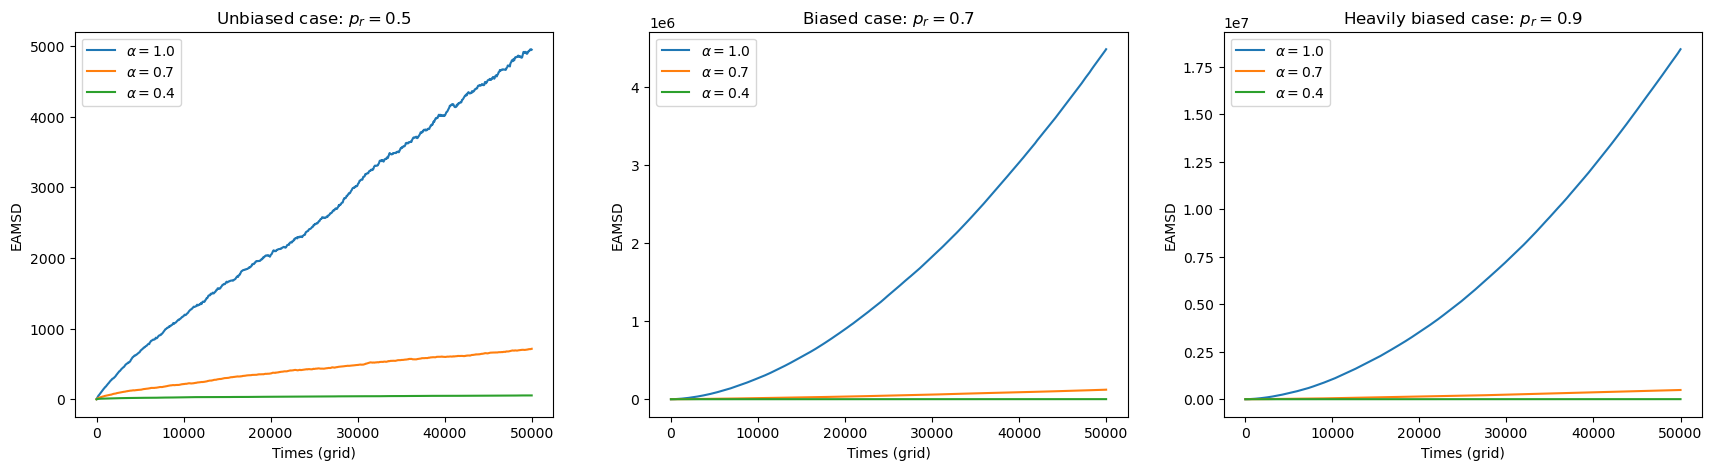

In [27]:
fig,ax = plt.subplots(1,3, figsize=(21,5))
ax = ax.flatten()

ax[0].plot(t_grid_1, eamsd_1, label=r'$\alpha=1.0$')
ax[0].plot(t_grid_07, eamsd_07, label=r'$\alpha=0.7$')
ax[0].plot(t_grid_04, eamsd_04, label=r'$\alpha=0.4$')
ax[0].legend()
ax[0].set_title('Unbiased case: $p_r = 0.5$')
ax[0].set_xlabel('Times (grid)')
ax[0].set_ylabel('EAMSD')

ax[1].plot(t_grid_b_1, eamsd_b_1, label=r'$\alpha=1.0$')
ax[1].plot(t_grid_b_07, eamsd_b_07, label=r'$\alpha=0.7$')
ax[1].plot(t_grid_b_04, eamsd_b_04, label=r'$\alpha=0.4$')
ax[1].legend()
ax[1].set_title('Biased case: $p_r = 0.7$')
ax[1].set_xlabel('Times (grid)')
ax[1].set_ylabel('EAMSD')

ax[2].plot(t_grid_hb_1, eamsd_hb_1, label=r'$\alpha=1.0$')
ax[2].plot(t_grid_hb_07, eamsd_hb_07, label=r'$\alpha=0.7$')
ax[2].plot(t_grid_hb_04, eamsd_hb_04, label=r'$\alpha=0.4$')
ax[2].legend()
ax[2].set_title('Heavily biased case: $p_r = 0.9$')
ax[2].set_xlabel('Times (grid)')
ax[2].set_ylabel('EAMSD')

plt.show()

The unbiased-case EAMSD scales linearly with time. The biased cases instead show a ballistic behaviour close to the origin, while they converge to a linear behaviour for large times. In the following, log-log plots show how the EAMSD follows a fixed-exponent relation with time. Optimal fitted parameters are calculated over the second half of data points, to make sure that initial fluctuations are ignored. In the end, the plots show that data in fact converges to a linear behaviour where the fitted coefficient are consistent with theoretical expectations. In particular, we should see $m\sim\alpha$ for the unbiased case and $m\sim 2\alpha$ for the biased cases. Deviations are non-negligible, but an infinite number of infinite trajectories is the only case where 100% accuracy can be expected.

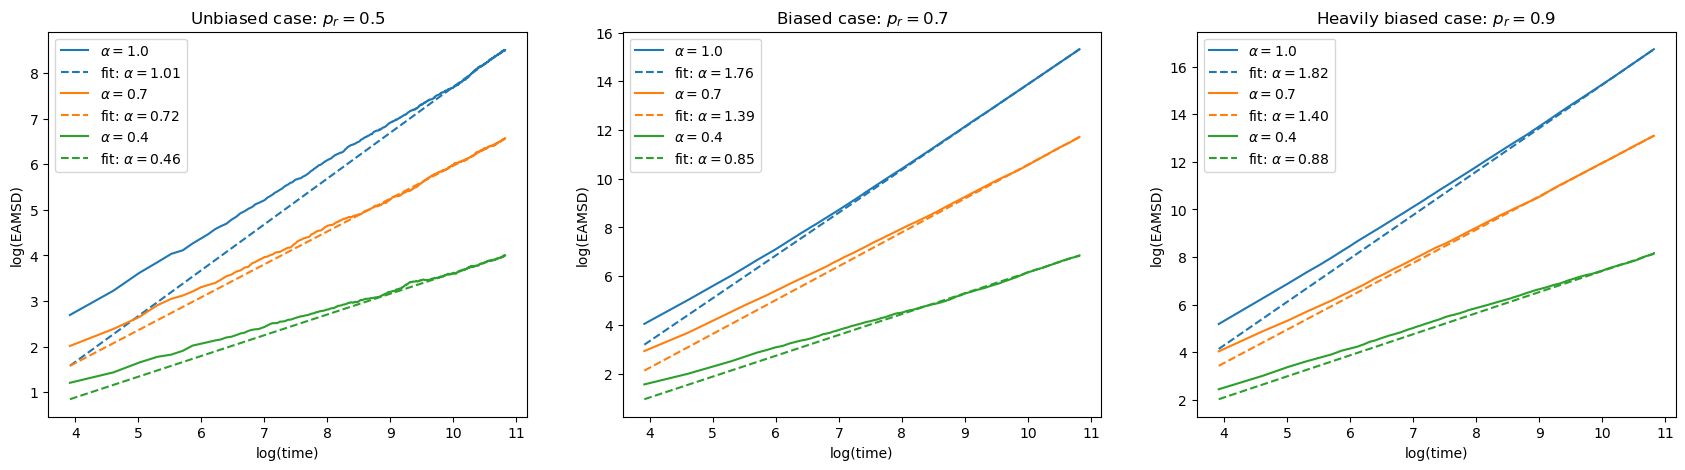

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(21, 5))
ax = ax.flatten()

def linear(x, m, q):
    return m*x + q

def linearfit_inrange(x, y, fit_range=None):
    
    # select array slices
    if fit_range is None:
        xf, yf = x, y
    else:
        xf, yf = x[fit_range], y[fit_range]
    
    # fit data to linear
    popt, pcov = curve_fit(linear, xf, yf)

    return popt[0], pcov[0,0], popt[1], pcov[1,1]

# subplot 0 - unbiased
datasets_0 = [
    (np.log(t_grid_1[1:]),    np.log(eamsd_1[1:]),    r'$\alpha=1.0$', 'C0'),
    (np.log(t_grid_07[1:]),   np.log(eamsd_07[1:]),   r'$\alpha=0.7$', 'C1'),
    (np.log(t_grid_04[1:]),   np.log(eamsd_04[1:]),   r'$\alpha=0.4$', 'C2'),
]
for (x, y, lbl, c) in datasets_0:
    third = slice(len(x) * 2 // 3, None)
    half = slice(len(x)//2, None)
    m, _, q, _ = linearfit_inrange(x, y, fit_range=half)
    ax[0].plot(x, y, c=c, label=f'{lbl}')
    ax[0].plot(x, linear(x, m, q), '--', c=c, label=rf'fit: $\alpha = {m:.2f}$')
ax[0].legend()
ax[0].set_title('Unbiased case: $p_r = 0.5$')
ax[0].set_xlabel('log(time)')
ax[0].set_ylabel('log(EAMSD)')

# subplot 1 - biased
datasets_1 = [
    (np.log(t_grid_b_1[1:]),    np.log(eamsd_b_1[1:]),    r'$\alpha=1.0$', 'C0'),
    (np.log(t_grid_b_07[1:]),   np.log(eamsd_b_07[1:]),   r'$\alpha=0.7$', 'C1'),
    (np.log(t_grid_b_04[1:]),   np.log(eamsd_b_04[1:]),   r'$\alpha=0.4$', 'C2'),
]
for (x, y, lbl,c) in datasets_1:
    third = slice(len(x) * 2 // 3, None)
    half = slice(len(x)//2, None)
    m, _, q, _ = linearfit_inrange(x, y, fit_range=half)
    ax[1].plot(x, y, c=c, label=f'{lbl}')
    ax[1].plot(x, linear(x, m, q), '--', c=c, label=rf'fit: $\alpha = {m:.2f}$')
ax[1].legend()
ax[1].set_title('Biased case: $p_r = 0.7$')
ax[1].set_xlabel('log(time)')
ax[1].set_ylabel('log(EAMSD)')

# subplot 2 - heavily biased
datasets_2 = [
    (np.log(t_grid_hb_1[1:]),    np.log(eamsd_hb_1[1:]),    r'$\alpha=1.0$', 'C0'),
    (np.log(t_grid_hb_07[1:]),   np.log(eamsd_hb_07[1:]),   r'$\alpha=0.7$', 'C1'),
    (np.log(t_grid_hb_04[1:]),   np.log(eamsd_hb_04[1:]),   r'$\alpha=0.4$', 'C2'),
]
for (x, y, lbl,c) in datasets_2:
    third = slice(len(x) * 2 // 3, None)
    half = slice(len(x)//2, None)
    m, _, q, _ = linearfit_inrange(x, y, fit_range=half)
    ax[2].plot(x, y, c=c, label=f'{lbl}')
    ax[2].plot(x, linear(x, m, q), '--', c=c, label=rf'fit: $\alpha = {m:.2f}$')
ax[2].legend()
ax[2].set_title('Heavily biased case: $p_r = 0.9$')
ax[2].set_xlabel('log(time)')
ax[2].set_ylabel('log(EAMSD)')

plt.show()

#### TAMSD
For the actual function used below, check previous cells (or the second overall code cell), since the tamsd is already computed in the ```analyze_ensemble``` function. It's clear that the TAMSD differs from the EAMSD, and that the dependence on time scales differently.

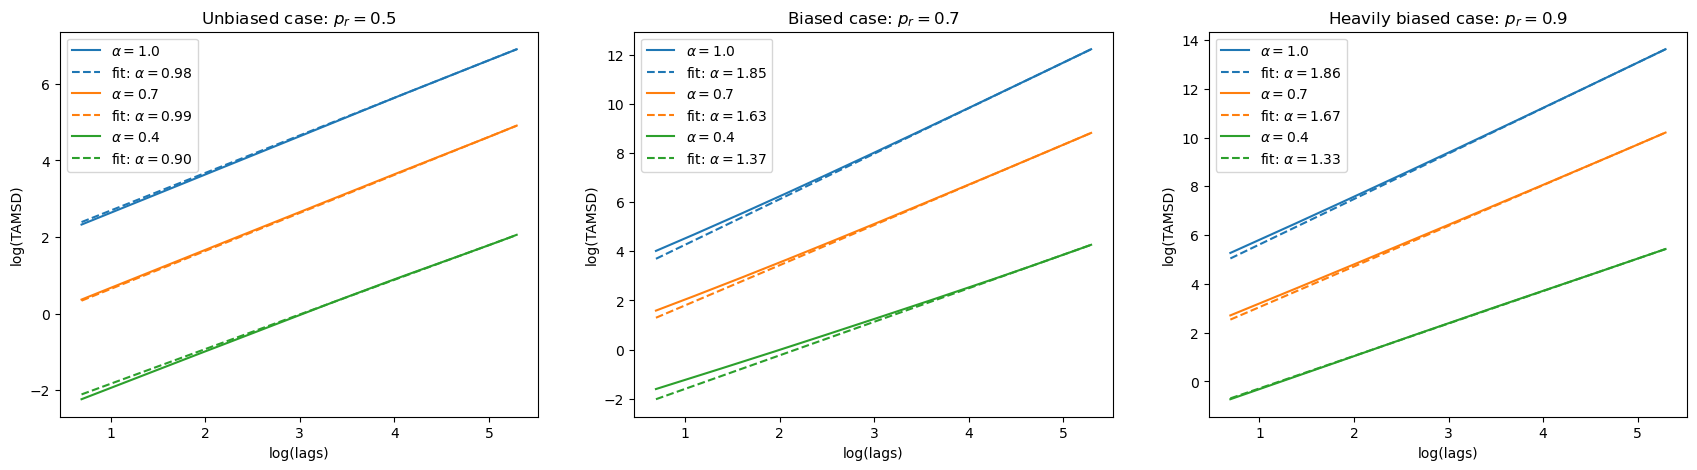

In [30]:
fig, ax = plt.subplots(1, 3, figsize=(21, 5))
ax = ax.flatten()

def linear(x, m, q):
    return m*x + q

def linearfit_inrange(x, y, fit_range=None):
    if fit_range is None:
        xf, yf = x, y
    else:
        xf, yf = x[fit_range], y[fit_range]
    popt, pcov = curve_fit(linear, xf, yf)
    return popt[0], pcov[0,0], popt[1], pcov[1,1]

# subplot 0 - unbiased
datasets_0 = [
    (np.log(lags_1[1:]),    np.log(tamsd_1[1:]),    r'$\alpha=1.0$', 'C0'),
    (np.log(lags_07[1:]),   np.log(tamsd_07[1:]),   r'$\alpha=0.7$', 'C1'),
    (np.log(lags_04[1:]),   np.log(tamsd_04[1:]),   r'$\alpha=0.4$', 'C2'),
]
for (x, y, lbl, c) in datasets_0:
    half = slice(len(x) // 2, None)
    m, _, q, _ = linearfit_inrange(x, y, fit_range=half)
    ax[0].plot(x, y, c=c, label=f'{lbl}')
    ax[0].plot(x, linear(x, m, q), '--', c=c, label=rf'fit: $\alpha = {m:.2f}$')
ax[0].legend()
ax[0].set_title('Unbiased case: $p_r = 0.5$')
ax[0].set_xlabel('log(lags)')
ax[0].set_ylabel('log(TAMSD)')

# subplot 1 - biased
datasets_1 = [
    (np.log(lags_b_1[1:]),    np.log(tamsd_b_1[1:]),    r'$\alpha=1.0$', 'C0'),
    (np.log(lags_b_07[1:]),   np.log(tamsd_b_07[1:]),   r'$\alpha=0.7$', 'C1'),
    (np.log(lags_b_04[1:]),   np.log(tamsd_b_04[1:]),   r'$\alpha=0.4$', 'C2'),
]
for (x, y, lbl, c) in datasets_1:
    half = slice(len(x) // 2, None)
    m, _, q, _ = linearfit_inrange(x, y, fit_range=half)
    ax[1].plot(x, y, c=c, label=f'{lbl}')
    ax[1].plot(x, linear(x, m, q), '--', c=c, label=rf'fit: $\alpha = {m:.2f}$')
ax[1].legend()
ax[1].set_title('Biased case: $p_r = 0.7$')
ax[1].set_xlabel('log(lags)')
ax[1].set_ylabel('log(TAMSD)')

# subplot 2 - heavily biased
datasets_2 = [
    (np.log(lags_hb_1[1:]),    np.log(tamsd_hb_1[1:]),    r'$\alpha=1.0$', 'C0'),
    (np.log(lags_hb_07[1:]),   np.log(tamsd_hb_07[1:]),   r'$\alpha=0.7$', 'C1'),
    (np.log(lags_hb_04[1:]),   np.log(tamsd_hb_04[1:]),   r'$\alpha=0.4$', 'C2'),
]
for (x, y, lbl, c) in datasets_2:
    half = slice(len(x) // 2, None)
    m, _, q, _ = linearfit_inrange(x, y, fit_range=half)
    ax[2].plot(x, y, c=c, label=f'{lbl}')
    ax[2].plot(x, linear(x, m, q), '--', c=c, label=rf'fit: $\alpha = {m:.2f}$')
ax[2].legend()
ax[2].set_title('Heavily biased case: $p_r = 0.9$')
ax[2].set_xlabel('log(lags)')
ax[2].set_ylabel('log(TAMSD)')

plt.show()

### Questions for discussion
- **How does the trajectory look when compared with a Brownian-like trajectory?** Biased trajectories show strong preference to jump towards the biased (preferred) direction; power-law-ctrw processes show longer and more frequent plateaus.
- **How do the plateaus depend on $\alpha$?** The smaller $\alpha$, the longer and more frequent the plateaus.
- **In the unbiased case, what exponent do you measure for the EAMSD?** The coefficient of the linear fit converges to $\alpha$.
- **In the biased case, what exponent do you measure for the displacement EAMSD?** Here, the coefficient is instead of order $2\alpha$.
- **Why does the mismatch between EAMSD and TAMSD indicate weak ergodicity breaking?** Because weak ergodicity breaking means that the TAMSD will converge to the EAMSD only in the infinite-time limit, and therefore must be different for any finite time, which is our case.

## 6. Decimation

We now coarse-grain the Markovian random walk by observing only every second site.
A convenient way to generate the decimated trajectory is:
- simulate the full nearest-neighbour Markov process,
- record only the successive visits to the even sublattice,
- measure the effective waiting times between those coarse-grained jumps.

For a biased nearest-neighbour Markov process, the decimated dynamics is generally non-Markovian.
The effective waiting-time distribution is no longer exponential.

### Exercise 6.1
Create the decimated trajectory by keeping only every second site.
Then measure the effective waiting-time distribution between successive jumps on the coarse lattice.

Compare the histogram with the analytical form derived in class.

In [37]:
def decimate(times, trajectory, mask_function):

    # create decimation mask and decimated vectors
    mask = np.array([mask_function(val) for val in trajectory], dtype=bool)
    dec_trajectory = trajectory[mask]
    dec_times = times[mask]
    
    # build coarse-indexed trajectory
    unique_values, coarse_trajectory_pos = np.unique(dec_trajectory, return_index=True)
    neg_count = np.sum((unique_values < 0).astype(int))
    coarse_trajectory = np.asarray([k - neg_count for k in coarse_trajectory_pos])
    coarse_times = dec_times[coarse_trajectory_pos]
    
    return dec_times, dec_trajectory, coarse_times, coarse_trajectory


def collect_decimated_waiting_times(mask_function, n_traj=1000, T=1000.0, alpha=1., tau0=1., p_right=0.5, x0=0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    
    all_cumulative_waiting_times = []
    k = 0
    while k<n_traj:
        times, trajectory = simulate_powerlaw_ctrw(T=T, alpha=alpha, tau0=tau0, p_right=p_right, x0=x0, rng=rng)
        _, _, dec_times, _ = decimate(times, trajectory, mask_function)
        all_cumulative_waiting_times.append(np.diff(dec_times))
        k += 1
    cumulative_waiting_times = np.concatenate(all_cumulative_waiting_times)

    lower = cumulative_waiting_times.min()
    if lower <= 0:
        lower = 1e-8
    higher = cumulative_waiting_times.max()
    n_bins = 50
    bin_edges = np.logspace(np.log10(lower), np.log10(higher), n_bins)
    values, bin_edges = np.histogram(cumulative_waiting_times, bins=bin_edges)
    bins = np.sqrt(bin_edges[:-1] * bin_edges[1:])

    return bins, values

Below, various processes get decimated both pairwise and non-pairwise. The waiting time distribution for pairwise decimation is the one theoretically expected (remove the "log" condition on the $x$ axis to recover the known shape). Non-pairwise decimation leads to a similar curve, with some differences.
- Whenever a site gets decimated, all jumps to this site aren't considered. Therefore, decimating two adjacent sites "a" and "b" removes all jumps both from "a" to "b" and vice-versa. Hence, the resulting WTD has lower counts for each bin and is smeared to the right when compared with a similar distribution, that has a single decimated site for each couple of decimated sites of the other one.
- The effect of leaving two adjacent sites unharmed is stronger than decimating both. In a system with decimated alternate pairs (...-O-O-X-X-O-O-X-X-...), the procedure is similar to lumping pairs and then decimating even sites, but the jumps between the non-decimated sites still count towards the total sum. This way, one can oppose and "heal" the effect of decimating adjacent sites by leaving some adjacent sites unharmed (see the green and red curves below).

In [38]:
def no_mask(x):
    return 1
non_dec_bins, non_dec_values = collect_decimated_waiting_times(no_mask)

def odd_mask_function(x):
    return 1 - x%2
dec_bins2, dec_values2 = collect_decimated_waiting_times(odd_mask_function)

def mult3_mask_function(x):
    y = 0
    if x%3==0:
        y = 1
    return y
dec_bins3, dec_values3 = collect_decimated_waiting_times(mult3_mask_function)

def altpairs_mask_function(x):
    y = 0
    if (x%4==0 or (x-1)%4==0):
        y = 1
    return y
dec_bins_altpairs, dec_values_altpairs = collect_decimated_waiting_times(altpairs_mask_function)

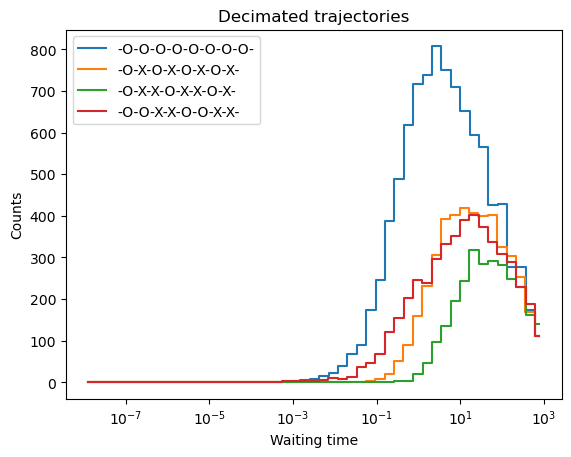

In [43]:
plt.step(non_dec_bins, non_dec_values, where='mid', label='-O-O-O-O-O-O-O-O-')
plt.step(dec_bins2, dec_values2, where='mid', label='-O-X-O-X-O-X-O-X-')
plt.step(dec_bins3, dec_values3, where='mid', label='-O-X-X-O-X-X-O-X-')
plt.step(dec_bins_altpairs, dec_values_altpairs, where='mid', label='-O-O-X-X-O-O-X-X-')


plt.xlabel('Waiting time')
plt.ylabel('Counts')
plt.xscale('log')
#plt.yscale('log')
#plt.xlim([-2,62])
plt.title('Decimated trajectories')
plt.legend()
plt.show()

## 7. Lumping

Now group adjacent sites into pairs.
For instance:
$$
\{0,1\}\to 0, \quad \{2,3\}\to 1, \quad \{-2,-1\}\to -1, \dots
$$

Again record the effective waiting times between successive coarse jumps.
This exercise should highlight the contrast between:
- decimation: deleting states,
- lumping: merging states.

The resulting coarse waiting-time distributions need not coincide.

### Exercise 7.1
Repeat the same analysis for lumping, by grouping adjacent sites in pairs.

Then compare the coarse waiting-time histogram with the decimation case.
What is the conceptual difference between deleting states and merging states?

In [46]:
def lump(times, trajectory, block_length):
    lump_trajectory = trajectory // block_length
    mask = np.concatenate(([True], lump_trajectory[1:] != lump_trajectory[:-1]))
    lump_ind = np.where(mask)[0]
    lump_times = times[lump_ind]
    lump_trajectory = lump_trajectory[lump_ind]
    return np.array(lump_times), np.array(lump_trajectory)

def collect_lumped_waiting_times(block_length, n_traj=1000, T=1000.0, alpha=1., tau0=1., p_right=0.5, x0=0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    
    all_cumulative_waiting_times = []
    k = 0
    while k<n_traj:
        times, trajectory = simulate_powerlaw_ctrw(T=T, alpha=alpha, tau0=tau0, p_right=p_right, x0=x0, rng=rng)
        lump_times, _ = lump(times, trajectory, block_length)
        all_cumulative_waiting_times.append(np.diff(lump_times))
        k += 1
    cumulative_waiting_times = np.concatenate(all_cumulative_waiting_times)

    lower = cumulative_waiting_times.min()
    if lower <= 0:
        lower = 1e-8
    higher = cumulative_waiting_times.max()
    n_bins = 50
    bin_edges = np.logspace(np.log10(lower), np.log10(higher), n_bins)
    values, bin_edges = np.histogram(cumulative_waiting_times, bins=bin_edges)
    bins = np.sqrt(bin_edges[:-1] * bin_edges[1:])

    return bins, values

The following simulates different ctrw and applies the above lumping procedure to each of them, with different lump sizes. Higher-size lumps imply that jumps happen less often, which means two things:
- less counts for each bin in the WTD;
- the WTD gets smeared to the right, towards higher waiting times.

This is what happens, in fact, as shown in the plots below. An interesting observation comes from the second plot: increasing the lump size leads to less signficiant changes in the WTD, which might mean convergence to an asymptotic distribution. This may possibly be connected to the "fixed point" representing the limit for repeated applications of the lumping procedure, because a 4-lumped trajectory isn't but a trajectory that has been pair-lumped twice, a 64-lumped trajectory is a trajectory that has been pair-lumped six times, and so on.

Another related note is on the smearing effect, that gets mitigated for higher lump sizes, up to the point at which the mean of the distribution doesn't appear to change. There must be a threshold for the lump size above which there are less overall jumps that, however, are distributed along a WTD that isn't significantly different from the WTDs of smaller-lumped trajectories.

In [47]:
lumped_bins2, lumped_values2 = collect_lumped_waiting_times(2)
lumped_bins3, lumped_values3 = collect_lumped_waiting_times(3)
lumped_bins4, lumped_values4 = collect_lumped_waiting_times(4)
lumped_bins5, lumped_values5 = collect_lumped_waiting_times(5)
lumped_bins10, lumped_values10 = collect_lumped_waiting_times(10)
lumped_bins20, lumped_values20 = collect_lumped_waiting_times(20)
lumped_bins100, lumped_values100 = collect_lumped_waiting_times(100)
lumped_bins200, lumped_values200 = collect_lumped_waiting_times(200)

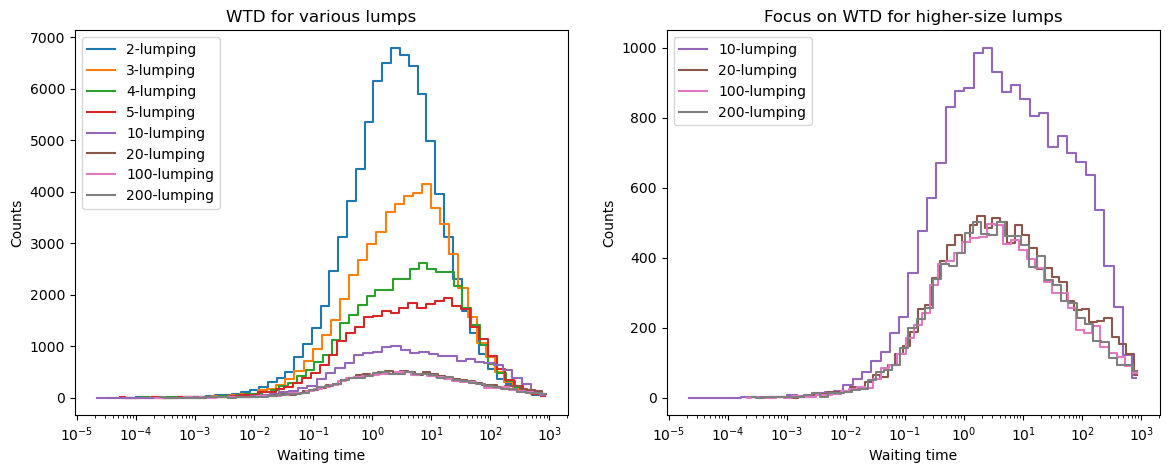

In [48]:
fig,ax = plt.subplots(1, 2, figsize=(14,5))
ax = ax.flatten()

# primo plot - all lumps
ax[0].step(lumped_bins2, lumped_values2, where='mid', label='2-lumping')
ax[0].step(lumped_bins3, lumped_values3, where='mid', label='3-lumping')
ax[0].step(lumped_bins4, lumped_values4, where='mid', label='4-lumping')
ax[0].step(lumped_bins5, lumped_values5, where='mid', label='5-lumping')
ax[0].step(lumped_bins10, lumped_values10, where='mid', label='10-lumping')
ax[0].step(lumped_bins20, lumped_values20, where='mid', label='20-lumping')
ax[0].step(lumped_bins100, lumped_values100, where='mid', label='100-lumping')
ax[0].step(lumped_bins200, lumped_values200, where='mid', label='200-lumping')
ax[0].set_xlabel('Waiting time')
ax[0].set_ylabel('Counts')
ax[0].set_xscale('log')
#ax[0].set_yscale('log')
ax[0].set_title('WTD for various lumps')
ax[0].legend()

# secondo plot - higher lumps
ax[1].step(lumped_bins10, lumped_values10, where='mid', c='C4', label='10-lumping')
ax[1].step(lumped_bins20, lumped_values20, where='mid', c='C5', label='20-lumping')
ax[1].step(lumped_bins100, lumped_values100, where='mid', c='C6', label='100-lumping')
ax[1].step(lumped_bins200, lumped_values200, where='mid', c='C7', label='200-lumping')
ax[1].set_xlabel('Waiting time')
ax[1].set_ylabel('Counts')
ax[1].set_xscale('log')
#ax[1].set_yscale('log')
ax[1].set_title('Focus on WTD for higher-size lumps')
ax[1].legend()

plt.show()

## 8. Homework: iterative RG under decimation

Try to implement the iterative renormalization-group scheme for decimation.
The target is to show numerically that, for waiting-time distributions with finite mean, repeated decimation flows toward the same fixed-point RTD discussed in class.

Suggested steps:
1. Start from several microscopic waiting-time laws with finite mean.
2. Compute the induced decimated RTD numerically.
3. Use the output as the input for the next decimation step.
4. Compare the rescaled RTDs after each iteration.
5. Test convergence toward the universal fixed point.

Possible extensions:
- compare finite-mean and infinite-mean cases,
- monitor moments when they exist,
- work in Laplace space if that is more convenient.

Several trajectories are decimated for a different number of times in the following. The resulting waiting times distribution, grouped by the number of iterations, are shown to quickly converge to a clear asymptotic distribution. The convergence becomes clear as soon as by the fourth consecutive decimation procedure.

In [49]:
def odd_mask_function(x):
    return 1 - x%2

In [85]:
n_traj = 10000
T = 1e5
iterations = 6

wt_temp = []
waiting_times = []

for ind in range(1,iterations+1):
    for N in range(n_traj):
        # initial trajectory
        curr_times, curr_traj = simulate_powerlaw_ctrw(T=1000.0, alpha=1., tau0=1.0, p_right=0.5, x0=0, rng=None)
        for k in range(ind):
            _, _, curr_times, curr_traj = decimate(curr_times, curr_traj, odd_mask_function)
        # collect waiting times
        temp = np.diff(curr_times)
        wt_temp.append([k for k in temp if k > 0]) # remove first negative value
    wt = np.concatenate(wt_temp)
    np.savez(f'ex8_data_iter{ind}',wt=wt)

In [86]:
# load data
for ind in range(1,iterations+1):
    data = np.load(f'ex8_data_iter{ind}.npz')
    waiting_times.append(data['wt'])

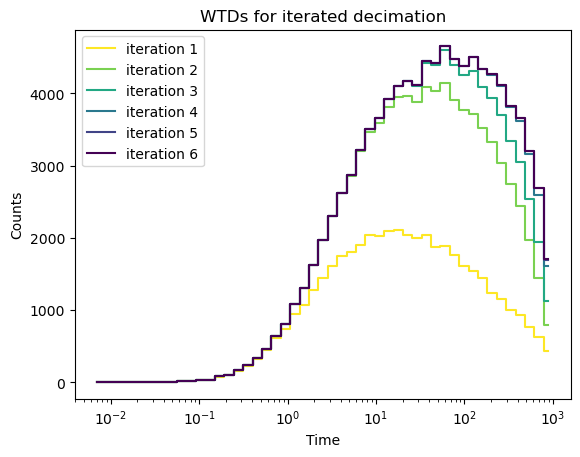

In [ ]:
out_values = []
out_bins = []
colors = plt.cm.viridis(np.linspace(0, 1, iterations))

for N in range(1,iterations+1):
    wt = waiting_times[N-1]

    lower = wt.min()
    if lower <= 0:
        lower = 1e-12
    higher = wt.max()
    n_bins = 50
    
    bin_edges = np.logspace(np.log10(lower), np.log10(higher), n_bins)
    values, bins_temp = np.histogram(wt, bins=bin_edges)
    bins = np.sqrt(bin_edges[:-1] * bins_temp[1:])
    plt.step(bins, values, where='mid', c=colors[iterations-N], label=f'iteration {N}')

plt.xscale('log')
plt.legend()
plt.title('WTDs for iterated decimation')
plt.xlabel('Time')
plt.ylabel('Counts')

plt.show()